<a href="https://colab.research.google.com/github/ChandraMouli2727/Rough/blob/main/DL/CNN_23_24_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disadvantages of using ANN for image classification

1. Too much computation
2. Treats local pixels same as pixels for apart
3. Sensitive to location of an object in an image
 # filters are nothing but the feature detectors
 * Image-->Detect loopy circle (using feature map) like eye,nose,ears-->head,body-->finalise using feature map -->flatten-->cnn
 * Feature Extraction ---> Classification

 * Relu helps with making the model nonlinear(make -ve values as zero keep it +ve values only)
 * pooling layer is used to reduce the size
 max pooling(general use)  img-->loopy pattern-->relu-->max pooling (gives even img is shifted find easily loopy pattern)
 * average pooling
 benefits of pooling --> 1)Reduces dimensions & computation ,2) Reduce overfiting as there are less parameters..3)Model is tolerant towards variations,distortions

 steps-->convolution --> pooling + Relu(add hidden layers u want) -->flatten (Dense layer)
 Feature Extraction--> classification(ANN)

#Convolution
* 1)Connections sparsity(Not every node is connected to another neuron/dense network) reduces overfiting
* 2)conv + pooling gives location invariant feature detection
* 3) parameter sharing(when u learn A value it will apply entire img)
 # ReLU
 1)introduces nonlinearity
 2)Speeds up training,faster to compute
 # Pooling
 1) Reduces dimensions and computation
 2)Reduces overfitting
 3)makes the model tolerant towards small distortion and variations

 CNN by itself doesn't take care of rotation and scale
 1)you need to have rotated,scaled samples in training dataset
 2)if you don't have such samples than use data augmentation methods to generate new rotated/scaled samples from existing training samples

In [2]:
import numpy as np
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np


In [3]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2618s 15us/step


In [4]:
x_train.shape,x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
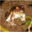

In [5]:
x_train[0]

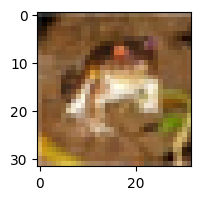

In [7]:
plt.figure(figsize=(15,2))
plt.imshow(x_train[0])


In [11]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [12]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [35]:
y_test = y_test.reshape(-1,)

In [36]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [37]:
def plot_sample(X,y,index):
  plt.figure(figsize=(15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

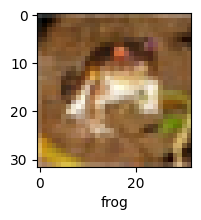

In [38]:
plot_sample(x_train,y_train,0)

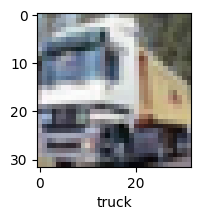

In [39]:
plot_sample(x_train,y_train,1)

In [40]:
x_train.shape

(50000, 32, 32, 3)

In [41]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [42]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

#
Build simple artificial neural network for image classification

In [48]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='sigmoid')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3560 - loss: 1.8124
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4280 - loss: 1.6231
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4557 - loss: 1.5395
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4786 - loss: 1.4828
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4959 - loss: 1.4335


In [49]:
ann.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4491 - loss: 1.5411


[1.541072130203247, 0.44909998774528503]

In [50]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.66      0.36      0.47      1000
           1       0.41      0.81      0.54      1000
           2       0.52      0.13      0.21      1000
           3       0.35      0.35      0.35      1000
           4       0.47      0.34      0.40      1000
           5       0.49      0.24      0.32      1000
           6       0.39      0.74      0.51      1000
           7       0.65      0.45      0.53      1000
           8       0.42      0.79      0.54      1000
           9       0.58      0.29      0.38      1000

    accuracy                           0.45     10000
   macro avg       0.49      0.45      0.42     10000
weighted avg       0.49      0.45      0.42     10000



1 : 0.45
2 : 0.67 it is sigmoid o/p

1 : (0.45)/(0.45+0.67) softmax o/p gives probability like total sum as 1
2 : (0.67)/(0.45+0.67)

# Now let us build a convolutional neural network to train images

In [52]:
cnn = models.Sequential([
         #cnn
         layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
         layers.MaxPooling2D((2,2)),

         layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3)),
         layers.MaxPooling2D((2,2)),
         #dense
         layers.Flatten(),
         layers.Dense(64, activation='relu'),
         layers.Dense(10, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [54]:
cnn.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4470 - loss: 1.5309
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5758 - loss: 1.2035
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6230 - loss: 1.0810
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6517 - loss: 0.9964
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6724 - loss: 0.9408
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6877 - loss: 0.8948
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7022 - loss: 0.8566
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7101 - loss: 0.8262
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7232 - loss: 0.7943
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7355 - loss: 0.7611


In [55]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6858 - loss: 0.9138


[0.9138129949569702, 0.6858000159263611]

In [56]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

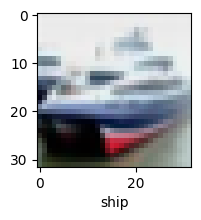

In [58]:
plot_sample(x_test,y_test,1)

In [63]:
y_pred = cnn.predict(x_test)
y_pred[:2]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[6.38249144e-02, 1.00011064e-04, 2.20789518e-02, 7.51616538e-01,
        3.87021736e-03, 9.87689644e-02, 2.53999457e-02, 5.84747968e-03,
        2.84269936e-02, 6.59581274e-05],
       [6.55235117e-03, 1.66541591e-01, 8.86459384e-05, 2.54464612e-05,
        3.95583720e-06, 5.19012247e-07, 1.22099914e-06, 1.97481927e-06,
        8.24890137e-01, 1.89415016e-03]], dtype=float32)

In [64]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [65]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [66]:
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [67]:
classes[y_classes[1]]

'ship'

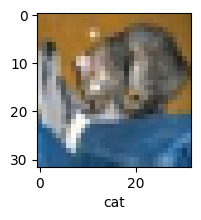

In [70]:
plot_sample(x_test,y_test,0)

In [71]:
classes[y_classes[0]]

'cat'

In [72]:
print("Classification Report: \n",classification_report(y_test,y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.69      0.78      0.73      1000
           1       0.77      0.82      0.80      1000
           2       0.59      0.54      0.56      1000
           3       0.52      0.45      0.48      1000
           4       0.67      0.58      0.62      1000
           5       0.57      0.62      0.59      1000
           6       0.76      0.77      0.76      1000
           7       0.70      0.76      0.73      1000
           8       0.74      0.83      0.78      1000
           9       0.82      0.71      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.68      0.69      0.68     10000



# Valid Convolution No Padding
  * 5 x 7 (m x n) * 3 x 3(f x f) = 3 x 5
  * (m-f+1)x(n-f+1)=(5-3+1)x(7-3+1) = 3 x 5

  #Disadvantage : Corner pixels don't contribute as much in feature detection
  # same Convolution pad such that output is same as input
  layers.Conv2D(16,3,padding='same',activation='relu')
  tf.keras.layers.Conv2D(filters,kernel_size,strides=(2,2),padding='valid',data_format=None)

# Exercise